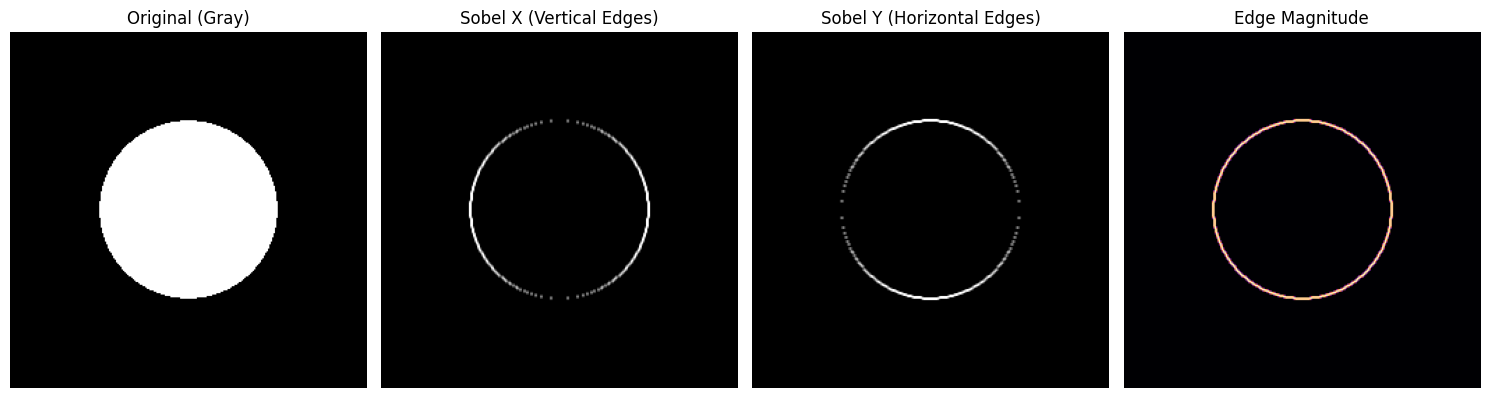

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.signal import convolve2d

# 1. 读取并预处理图像
# 如果你有自己的图片，请把 'test_image.png' 换成路径
# 这里如果没有图片，我们手动创建一个带圆圈的测试图
def create_test_image():
    x = np.linspace(-1, 1, 256)
    y = np.linspace(-1, 1, 256)
    X, Y = np.meshgrid(x, y)
    img = np.sqrt(X**2 + Y**2) < 0.5
    return (img * 255).astype(np.uint8)

# 加载图像 (转为灰度图是边缘检测的标准做法)
# img = np.array(Image.open('your_photo.jpg').convert('L'))
img = create_test_image()

# 2. 定义 Sobel 算子
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

# 3. 执行二维卷积
# boundary='symm' 处理边缘填充，mode='same' 保持图像尺寸不变
gx = convolve2d(img, sobel_x, mode='same', boundary='symm')
gy = convolve2d(img, sobel_y, mode='same', boundary='symm')

# 4. 计算梯度幅值 (Magnitude)
# 结合两个方向的梯度，得到最终边缘
magnitude = np.sqrt(gx**2 + gy**2)

# 归一化到 0-255 方便显示
magnitude = (magnitude / magnitude.max()) * 255

# 5. 可视化
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.title("Original (Gray)")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.title("Sobel X (Vertical Edges)")
plt.imshow(np.abs(gx), cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.title("Sobel Y (Horizontal Edges)")
plt.imshow(np.abs(gy), cmap='gray')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.title("Edge Magnitude")
plt.imshow(magnitude, cmap='magma') # 使用彩色映射看得更清楚
plt.axis('off')

plt.tight_layout()
plt.show()